#Problem statement: we want to predict performsnce of student on (performance index) based on
1.hours_studied
2.previous_scroes
3.extracurricular_activity
4.sleep_hours
5.sample_question


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:
df=pd.read_csv("/content/Student_dataset.csv")

In [ ]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23
9996,7,64,Yes,8,5,58
9997,6,83,Yes,8,5,74
9998,9,97,Yes,7,0,95


In [ ]:
df.shape


(10000, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     10000 non-null  int64 
 1   Previous Scores                   10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Sleep Hours                       10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance Index                 10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours Studied,9873.0,4.992100,2.589081,1.0,3.0,5.0,7.0,9.0
Previous Scores,9873.0,69.441102,17.325601,40.0,54.0,69.0,85.0,99.0
Sleep Hours,9873.0,6.531652,1.697683,4.0,5.0,7.0,8.0,9.0
Sample Question Papers Practiced,9873.0,4.583004,2.867202,0.0,2.0,5.0,7.0,9.0
Performance Index,9873.0,55.216651,19.208570,10.0,40.0,55.0,70.0,100.0


In [ ]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
df.duplicated().sum()

np.int64(127)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(9873, 6)

In [ ]:
df["Extracurricular Activities"].unique()

array(['Yes', 'No'], dtype=object)

#Feature engineering : for yes-1 and no - 0

In [ ]:
df["Extracurricular Activities"]=df["Extracurricular Activities"].map({"Yes":1,"No":0})

In [ ]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91
1,4,82,0,4,2,65
2,8,51,1,7,2,45
3,5,52,1,5,2,36
4,7,75,0,8,5,66
...,...,...,...,...,...,...
9995,1,49,1,4,2,23
9996,7,64,1,8,5,58
9997,6,83,1,8,5,74
9998,9,97,1,7,0,95


# finding outlier

In [ ]:
def remove_outlier(df,columns):
  q1=df[columns].quantile(0.25)
  q3=df[columns].quantile(0.75)

  IQR=q3-q1
  lower_bound=q1-1.5*IQR
  upper_bound=q3+1.5*IQR
  return df[(df[columns]>=lower_bound) & (df[columns]<=upper_bound)]

In [ ]:
for col in df.columns:
  df=remove_outlier(df,col)

In [ ]:
df.shape

(9873, 6)

# univariant analysis

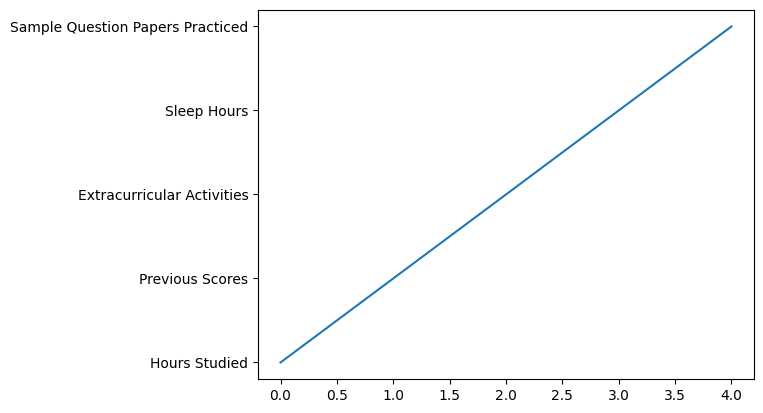

In [ ]:
plt.plot(["Hours Studied","Previous Scores","Extracurricular Activities","Sleep Hours","Sample Question Papers Practiced"])
plt.show()

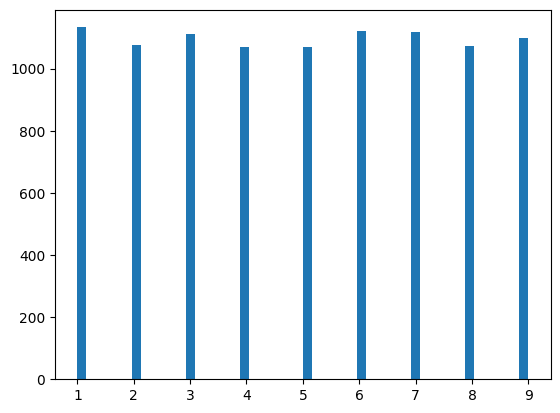

In [ ]:
plt.hist(df["Hours Studied"],bins=50)
plt.show()

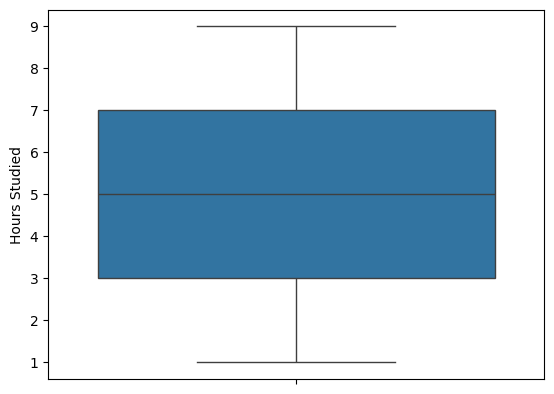

In [ ]:
sns.boxplot(df["Hours Studied"])
plt.show()

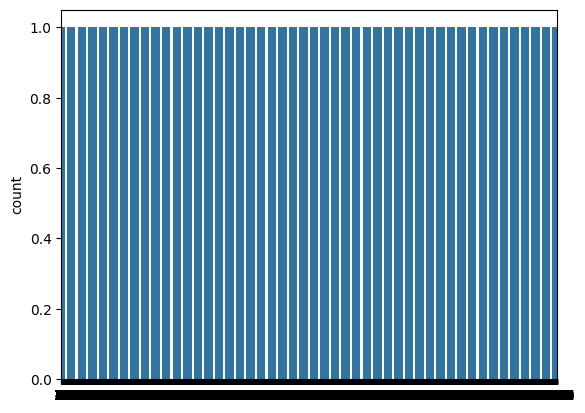

In [ ]:
sns.countplot(df["Hours Studied"])
plt.show()

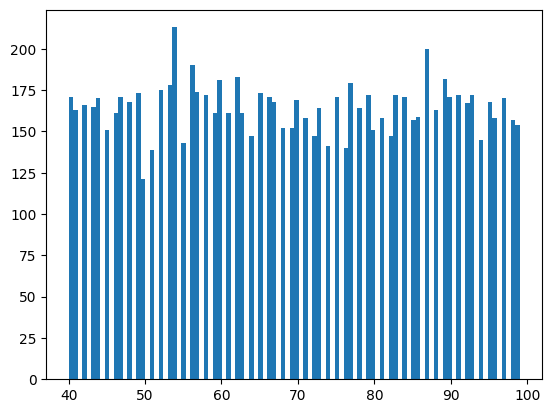

In [ ]:
plt.hist(df["Previous Scores"],bins=100)
plt.show()

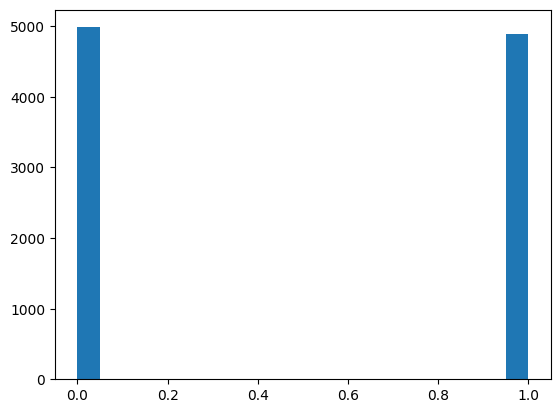

In [ ]:
plt.hist(df["Extracurricular Activities"],bins=20)
plt.show()

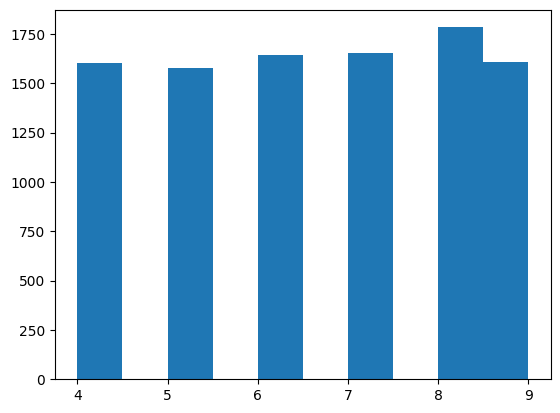

In [ ]:
plt.hist(df["Sleep Hours"],bins=10)
plt.show()

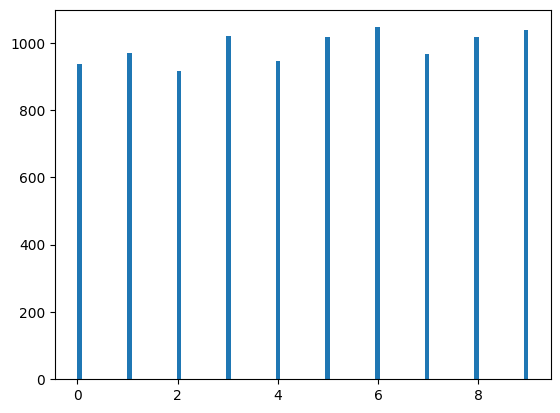

In [ ]:
plt.hist(df["Sample Question Papers Practiced"],bins=100)
plt.show()

# bivariance analysis

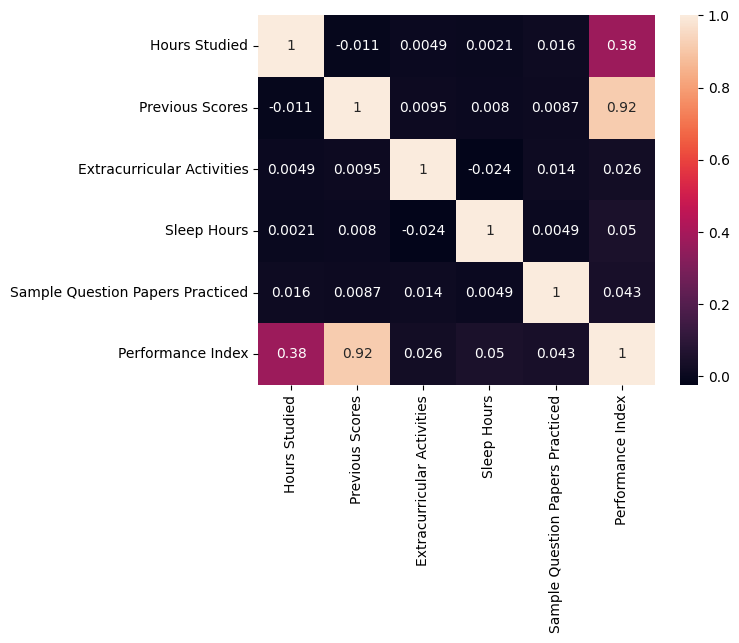

In [ ]:
sns.heatmap(df.corr(),annot=True)
plt.show()

# ML Model_buliding

# creating two variables for train module

In [ ]:
X=df.drop("Performance Index",axis=1)
y=df["Performance Index"]

# apply train_test_module

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.7)

# linear regrassion model apply on dataset

In [ ]:
lr=LinearRegression()

In [ ]:
lr.fit(X_train,y_train)


LinearRegression()

# Evaluated Model parameter

In [ ]:
lr.intercept_

np.float64(-33.89758864708254)

In [ ]:
lr.coef_

array([2.85068228, 1.01638612, 0.64606679, 0.47582652, 0.19051175])

# Model evaluation

In [ ]:
y_pred=lr.predict(X_test)

# compare y_pread and y_test

In [ ]:
print("MAE: ",metrics.mean_absolute_error(y_test,y_pred))
print("MSE: ",metrics.mean_squared_error(y_test,y_pred))
print("R2: ",metrics.r2_score(y_pred,y_test))


MAE:  1.6249248914795924
MSE:  4.102658514229841
R2:  0.9887158554311876


# Here we get the our model ready and find 98% accuracy

# new data for test the module
1.Hours Studied = 5
2.Previous Scores = 75
3.Extracurricular Activities= 1
4.Sleep Hours = 8
5.Sample Question Papers Practiced = 7

In [ ]:
new_student={"Hours Studied":7,
"Previous Scores":85,
"Extracurricular Activities":1,
"Sleep Hours":8,
"Sample Question Papers Practiced":7}

In [ ]:
df_new_student=pd.DataFrame(new_student,index=[0])

In [ ]:
df_new_student

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,85,1,8,7


# we check predicted value for new student

In [ ]:
y_pred=lr.predict(df_new_student)

In [ ]:
y_pred

array([78.23626891])

# above result show that student might score 78% in exam